In [16]:
!pip install segmentation_models_pytorch
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 9.6 MB/s  0:00:00a 0:00:01m eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=cf40029a4490683e9b51af9c9e26a60c80084750fa5e473c1e5ebce9495e36eb
  Stored in directory: /home/andy/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [grad-cam]


In [36]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from scipy.stats import kurtosis
from skimage.feature import graycomatrix, graycoprops
import segmentation_models_pytorch as smp

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve,
     auc
)

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo in uso: {device}")

Dispositivo in uso: cuda


In [4]:
def estrai_features_qc(image_path):
    """Estrae le feature strutturali dall'immagine per il Random Forest"""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    
    features = {}
    features['hist_kurtosis'] = kurtosis(img.flatten())
    
    edges = cv2.Canny(img, 100, 200)
    features['edge_density'] = np.sum(edges) / (img.shape[0] * img.shape[1])
    features['border_center_ratio'] = 1.0 
    
    glcm = graycomatrix(img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    features['glcm_contrast'] = graycoprops(glcm, 'contrast')[0, 0]
    features['glcm_homogeneity'] = graycoprops(glcm, 'homogeneity')[0, 0]
    features['glcm_energy'] = graycoprops(glcm, 'energy')[0, 0]
    
    moments = cv2.moments(img)
    hu = cv2.HuMoments(moments).flatten()
    features['hu_moment_1'] = -np.sign(hu[0]) * np.log10(np.abs(hu[0]) + 1e-10)
    features['hu_moment_2'] = -np.sign(hu[1]) * np.log10(np.abs(hu[1]) + 1e-10)
    features['hu_moment_4'] = -np.sign(hu[3]) * np.log10(np.abs(hu[3]) + 1e-10)
    features['hu_moment_5'] = -np.sign(hu[4]) * np.log10(np.abs(hu[4]) + 1e-10)
    features['hu_moment_6'] = -np.sign(hu[5]) * np.log10(np.abs(hu[5]) + 1e-10)
    
    return features


In [5]:
class UNet_ResNet_Pipeline(nn.Module):
    def __init__(self):
        super(UNet_ResNet_Pipeline, self).__init__()
        
        self.unet = smp.Unet(
            encoder_name="resnet34",        
            encoder_weights="imagenet",     
            in_channels=1,
            classes=1                       
        )

        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        pesi_originali = self.resnet.conv1.weight.clone()
        
        self.resnet.conv1 = nn.Conv2d(
            in_channels=1, 
            out_channels=64, 
            kernel_size=7, 
            stride=2, 
            padding=3, 
            bias=False
        )

        with torch.no_grad():
            self.resnet.conv1.weight = nn.Parameter(torch.sum(pesi_originali, dim=1, keepdim=True))
            
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(num_ftrs, 2)

    def forward(self, x):
        mask_logits = self.unet(x)
        mask_probs = torch.sigmoid(mask_logits)
        
        x_masked = x * mask_probs 
        
        class_output = self.resnet(x_masked)
        
        return class_output, mask_probs, x_masked

In [6]:
def setup_dataloaders(data_dir, transform_train, transform_test, percorso_modello_rf, batch_size=32, seed=42, file_cache="qc_cache.json"):
    """Crea i dataloader filtrando i falsi positivi a monte (Con Progress Bar e Data Checkpoint)"""
    
    print("Caricamento modello Gatekeeper (Controllo Qualità)...")
    pacchetto = joblib.load(percorso_modello_rf)
    rf_model = pacchetto['modello_rf']
    features_richieste = pacchetto['feature_names']
    
    cache_qualita = {}
    
    if os.path.exists(file_cache):
        print(f"Trovato Checkpoint del Gatekeeper ('{file_cache}')! Caricamento istantaneo...")
        with open(file_cache, 'r') as f:
            cache_qualita = json.load(f)
    else:
        estensioni_valide = ('.png', '.jpg', '.jpeg', '.jp2', '.dicom', '.dcm', '.bmp')
        tutti_i_file = []
        
        for root, dirs, files in os.walk(data_dir):
            for file in files:
                if file.lower().endswith(estensioni_valide):
                    tutti_i_file.append(os.path.join(root, file))
                    
        print(f"Avvio analisi geometrica e strutturale su {len(tutti_i_file)} radiografie...")
        
        for percorso in tqdm(tutti_i_file, desc="Gatekeeper QC", colour='magenta'):
            try:
                features = estrai_features_qc(percorso) 
                if features is None:
                    cache_qualita[percorso] = False
                    continue
                
                X_pred = pd.DataFrame([features])[features_richieste]
                predizione = rf_model.predict(X_pred)[0]
                
                cache_qualita[percorso] = bool(predizione == 1 or predizione == "Perfetta") 
            except Exception:
                cache_qualita[percorso] = False
                
        with open(file_cache, 'w') as f:
            json.dump(cache_qualita, f, indent=4)
        print("Checkpoint del Controllo Qualità salvato su disco!")

    def filtro_veloce(percorso):
        return cache_qualita.get(percorso, False)

    print("Applicazione dei filtri a PyTorch e split dei dati...")
    
    dataset_aug = datasets.ImageFolder(data_dir, transform=transform_train, is_valid_file=filtro_veloce)
    dataset_base = datasets.ImageFolder(data_dir, transform=transform_test, is_valid_file=filtro_veloce)
    
    ds_size = len(dataset_aug)
    print(f"Operazione completata! Immagini accettate (Qualità Ottima): {ds_size}")
    if ds_size == 0:
        raise ValueError("ERRORE GRAVE: Tutte le immagini scartate. Controlla il modello RF.")
        
    train_size = int(0.7 * ds_size)
    val_size = int(0.2 * ds_size)
    test_size = ds_size - train_size - val_size
    
    gen_train = torch.Generator().manual_seed(seed)
    train_ds, _, _ = random_split(dataset_aug, [train_size, val_size, test_size], generator=gen_train)
    
    gen_val_test = torch.Generator().manual_seed(seed)
    _, val_ds, test_ds = random_split(dataset_base, [train_size, val_size, test_size], generator=gen_val_test)
    
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4)
    )

In [7]:
def esegui_training(modello, train_loader, val_loader, percorso_modello, percorso_json, epochs=20, patience=5, lr=1e-4, resume=False):
    criterio = nn.CrossEntropyLoss()
    ottimizzatore = optim.Adam(modello.parameters(), lr=lr)
    
    storia = {
        "train_loss": [], "train_acc": [], "train_precision": [], "train_recall": [], "train_f1": [],
        "val_loss": [], "val_acc": [], "val_precision": [], "val_recall": [], "val_f1": []
    }
    
    epoca_di_partenza = 0
    miglior_val_loss = float('inf')
    epoche_pazienza = 0

    if resume and os.path.exists(percorso_json) and os.path.exists(percorso_modello):
        print("Trovati salvataggi precedenti! Ripristino lo stato dell'addestramento...")
        modello.load_state_dict(torch.load(percorso_modello))
        
        with open(percorso_json, 'r') as f:
            storia = json.load(f)
            
        epoca_di_partenza = len(storia['train_loss'])
        
        if epoca_di_partenza > 0:
            miglior_val_loss = min(storia['val_loss'])
            indice_migliore = storia['val_loss'].index(miglior_val_loss)
            epoche_pazienza = epoca_di_partenza - 1 - indice_migliore
            
            print(f"Riparto dall'Epoca {epoca_di_partenza + 1}!")
            print(f"Pazienza ripristinata: {epoche_pazienza}/{patience} (Loss migliore all'epoca {indice_migliore + 1})")
            
        if epoca_di_partenza >= epochs:
            print("L'addestramento ha già raggiunto il numero massimo di epoche richieste.")
            return
    elif resume:
        print("Richiesto resume, ma non ho trovato i file. Parto da zero.")

    for epoca in range(epoca_di_partenza, epochs):
        print(f"\n--- Epoca {epoca+1}/{epochs} ---")
        
        modello.train()
        train_loss = 0.0
        all_y_train, all_pred_train = [], []
        
        for img, etic in tqdm(train_loader, desc="Train", leave=False, colour='blue'):
            img, etic = img.to(device), etic.to(device)
            ottimizzatore.zero_grad()
            
            out, _, _ = modello(img)
            
            loss = criterio(out, etic)
            loss.backward()
            ottimizzatore.step()
            
            train_loss += loss.item() * img.size(0)
            _, pred = torch.max(out, 1)
            all_y_train.extend(etic.cpu().numpy())
            all_pred_train.extend(pred.cpu().numpy())

        train_loss /= len(train_loader.dataset)
        train_acc = accuracy_score(all_y_train, all_pred_train)
        train_prec = precision_score(all_y_train, all_pred_train, zero_division=0)
        train_rec = recall_score(all_y_train, all_pred_train, zero_division=0)
        train_f1 = f1_score(all_y_train, all_pred_train, zero_division=0)
        
        modello.eval()
        val_loss = 0.0
        all_y_val, all_pred_val = [], []
        
        with torch.no_grad():
            for img, etic in tqdm(val_loader, desc="Val", leave=False, colour='green'):
                img, etic = img.to(device), etic.to(device)
                
                out, _, _ = modello(img)
                
                loss = criterio(out, etic)
                val_loss += loss.item() * img.size(0)
                _, pred = torch.max(out, 1)
                all_y_val.extend(etic.cpu().numpy())
                all_pred_val.extend(pred.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(all_y_val, all_pred_val)
        val_prec = precision_score(all_y_val, all_pred_val, zero_division=0)
        val_rec = recall_score(all_y_val, all_pred_val, zero_division=0)
        val_f1 = f1_score(all_y_val, all_pred_val, zero_division=0)

        print(f"Train - Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"Val   - Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

        storia["train_loss"].append(train_loss); storia["train_acc"].append(train_acc)
        storia["train_precision"].append(train_prec); storia["train_recall"].append(train_rec); storia["train_f1"].append(train_f1)
        storia["val_loss"].append(val_loss); storia["val_acc"].append(val_acc)
        storia["val_precision"].append(val_prec); storia["val_recall"].append(val_rec); storia["val_f1"].append(val_f1)
        
        with open(percorso_json, 'w') as f: json.dump(storia, f, indent=4)

        if val_loss < miglior_val_loss:
            miglior_val_loss = val_loss
            epoche_pazienza = 0
            torch.save(modello.state_dict(), percorso_modello)
            print("Checkpoint salvato.")
        else:
            epoche_pazienza += 1
            if epoche_pazienza >= patience:
                print(f"Early Stopping all'epoca {epoca+1}")
                break


In [26]:
def traccia_grafici_training(percorso_json):
    """Genera 3 grafici distinti ottimizzati per l'inserimento nella tesi"""
    with open(percorso_json, 'r') as f: storia = json.load(f)
    epoche = range(1, len(storia['train_loss']) + 1)
    miglior_epoca_idx = np.argmin(storia['val_loss'])
    miglior_epoca = miglior_epoca_idx + 1
    
    plt.figure(figsize=(8, 5))
    plt.plot(epoche, storia['train_loss'], label='Train Loss', color='blue', linewidth=2)
    plt.plot(epoche, storia['val_loss'], label='Validation Loss', color='red', linewidth=2)
    plt.axvline(x=miglior_epoca, color='black', linestyle='--', label=f'Miglior Ep. ({miglior_epoca})')
    
    if miglior_epoca < len(epoche):
        plt.fill_between(epoche[miglior_epoca_idx:], storia['train_loss'][miglior_epoca_idx:], 
                         storia['val_loss'][miglior_epoca_idx:], color='red', alpha=0.1, label='Overfitting')
                         
    plt.title('Dinamica della Loss e Overfitting', fontsize=14, fontweight='bold')
    plt.xlabel('Epoche'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

    def traccia_pannello_singolo(titolo, loss_data, acc_data, prec_data, rec_data, f1_data, loss_color):
        fig, ax1 = plt.subplots(figsize=(8, 5))
        
        ax1.plot(epoche, acc_data, label='Accuracy', color='purple', linewidth=2)
        ax1.plot(epoche, prec_data, label='Precision', color='green', linestyle='-.')
        ax1.plot(epoche, rec_data, label='Recall', color='orange', linestyle='-.')
        ax1.plot(epoche, f1_data, label='F1-Score', color='brown', linewidth=2)
        
        ax1.set_xlabel('Epoche', fontsize=12)
        ax1.set_ylabel('Metriche (0.0 - 1.0)', color='black', fontsize=12)
        ax1.set_ylim([0, 1.05])
        ax1.grid(True, linestyle=':', alpha=0.7)
        
        ax2 = ax1.twinx()
        ax2.plot(epoche, loss_data, label='Loss', color=loss_color, linewidth=3, linestyle='--')
        ax2.set_ylabel('Loss (CrossEntropy)', color=loss_color, fontsize=12)
        ax2.tick_params(axis='y', labelcolor=loss_color)
        
        ax2.axvline(x=miglior_epoca, color='black', linestyle=':', alpha=0.5)
        
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')
        
        plt.title(titolo, fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    traccia_pannello_singolo('Performance sul Set di Addestramento (Train)', 
                             storia['train_loss'], storia['train_acc'], 
                             storia['train_precision'], storia['train_recall'], 
                             storia['train_f1'], loss_color='blue')

    traccia_pannello_singolo('Performance sul Set di Validazione (Val)', 
                             storia['val_loss'], storia['val_acc'], 
                             storia['val_precision'], storia['val_recall'], 
                             storia['val_f1'], loss_color='red')

def valuta_modello_test(modello, test_loader, percorso_modello):
    """Carica il miglior modello e stampa Matrice di Confusione, AUC e Report (CON ETICHETTE CORRETTE)"""
    modello.load_state_dict(torch.load(percorso_modello))
    modello.eval()
    all_y, all_pred, all_probs = [], [], []
    
    with torch.no_grad():
        for img, etic in tqdm(test_loader, desc="Test Inferenza", colour='cyan'):
            img = img.to(device)
            out, _, _ = modello(img)
            
            all_y.extend(etic.cpu().numpy())
            all_pred.extend(torch.max(out, 1)[1].cpu().numpy())
            
            probs = F.softmax(out, dim=1)[:, 0]
            all_probs.extend(probs.cpu().numpy())
            
    cm = confusion_matrix(all_y, all_pred)
    
    auc_test = roc_auc_score(1 - np.array(all_y), all_probs)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Malato (0)', 'Sano (1)'], 
                yticklabels=['Malato', 'Sano'])
    
    plt.title(f'Matrice di Confusione (Test)\nAUC-ROC: {auc_test:.3f}', fontsize=14, fontweight='bold')
    plt.ylabel('Verità (Ground Truth)'); plt.xlabel('Predizione AI')
    plt.show()
    
    print("\nREPORT CLINICO FINALE (Sul Test Set):\n")
    print(classification_report(all_y, all_pred, target_names=['Malato', 'Sano']))
    print(f"AUC-ROC Finale: {auc_test:.4f}")

Pipeline con Data Augmentation
Caricamento modello Gatekeeper (Controllo Qualità)...
Trovato Checkpoint del Gatekeeper ('qc_cache.json')! Caricamento istantaneo...
Applicazione dei filtri a PyTorch e split dei dati...
Operazione completata! Immagini accettate (Qualità Ottima): 763


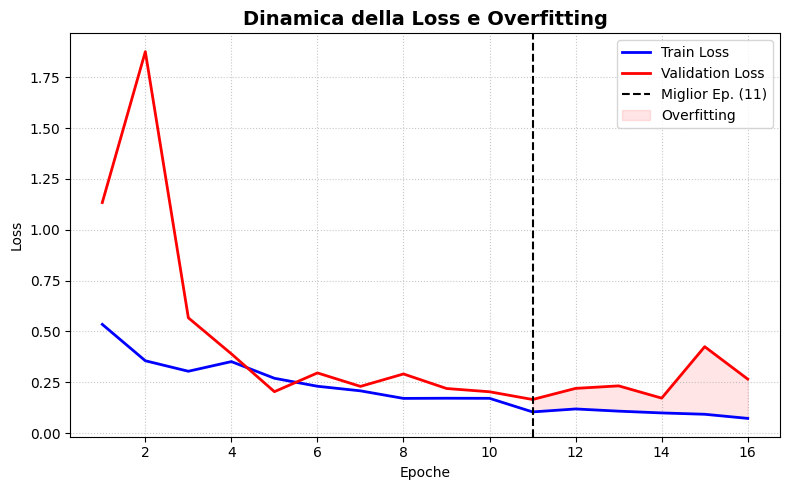

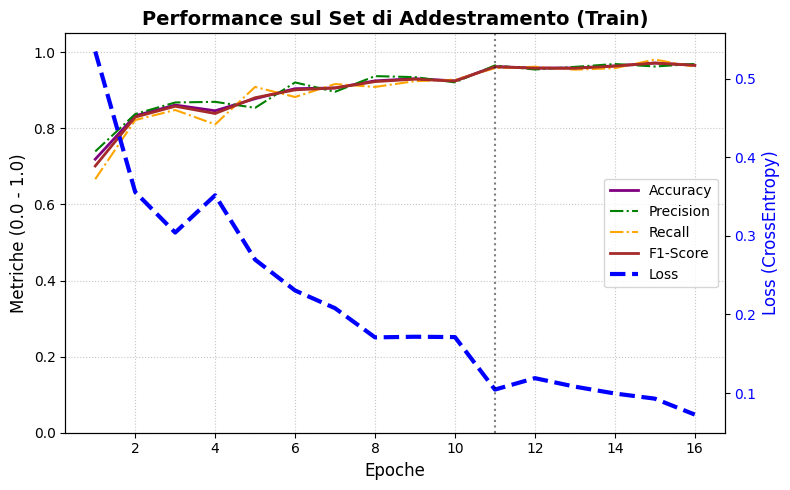

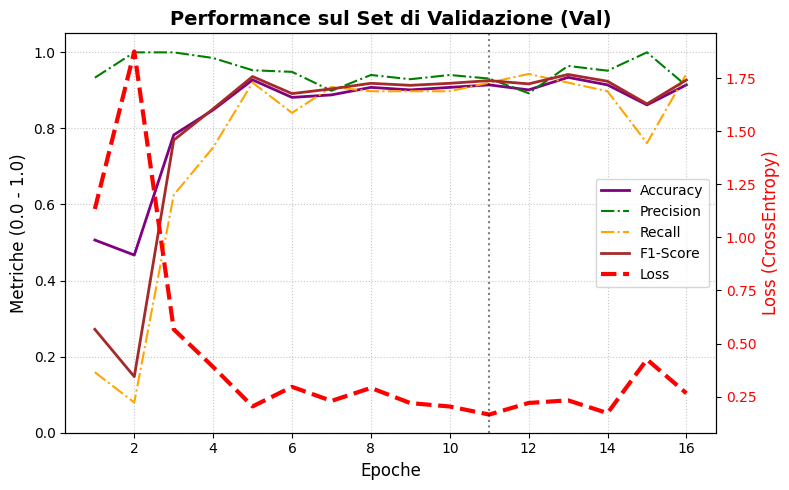

Test Inferenza: 100%|██████████| 3/3 [01:10<00:00, 23.35s/it]


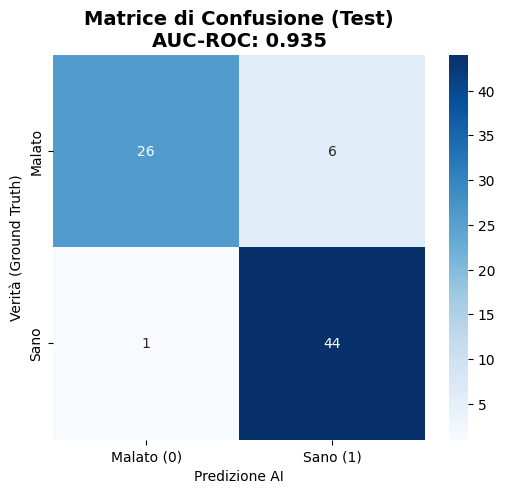


REPORT CLINICO FINALE (Sul Test Set):

              precision    recall  f1-score   support

      Malato       0.96      0.81      0.88        32
        Sano       0.88      0.98      0.93        45

    accuracy                           0.91        77
   macro avg       0.92      0.90      0.90        77
weighted avg       0.91      0.91      0.91        77

AUC-ROC Finale: 0.9354


In [28]:
print("Pipeline con Data Augmentation")

DIR_DATI = '/home/andy/Documenti/Tesi-Magistrale/data/RX_super'
percorso_joblib = '/home/andy/Documenti/Tesi-Magistrale/models_saved/controllo_qualita/controllo_qualita.joblib'
percorso_pth_aug = '/home/andy/Documenti/Tesi-Magistrale/models_saved/immagini/modello_con_aug.pth'
percorso_json_aug = '/home/andy/Documenti/Tesi-Magistrale/models_saved/immagini/risultati_con_aug.json'

transform_base = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

transform_aug = transforms.Compose([
    transforms.Grayscale(1), 
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomRotation(10),
    transforms.ToTensor(), 
    transforms.Normalize([0.5], [0.5])
])

train_loader_aug, val_loader_aug, test_loader_aug = setup_dataloaders(
    data_dir=DIR_DATI, 
    transform_train=transform_aug, 
    transform_test=transform_base,
    percorso_modello_rf=percorso_joblib
)

modello_aug = UNet_ResNet_Pipeline().to(device)

#esegui_training(modello_aug, train_loader_aug, val_loader_aug, percorso_pth_aug, percorso_json_aug, epochs=20, patience=5, resume=True)

traccia_grafici_training(percorso_json_aug)
valuta_modello_test(modello_aug, test_loader_aug, percorso_pth_aug)

Estrazione Probabilità in corso (1 solo passaggio per evitare OOM)...


Test Inferenza: 100%|██████████| 3/3 [01:08<00:00, 22.92s/it]


La Soglia Ottimale calcolata con l'Indice di Youden è: 0.4132


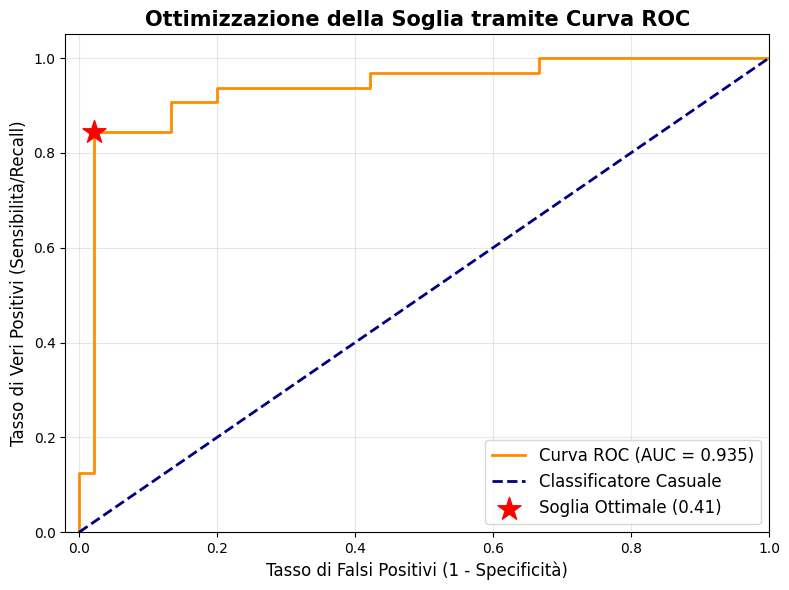

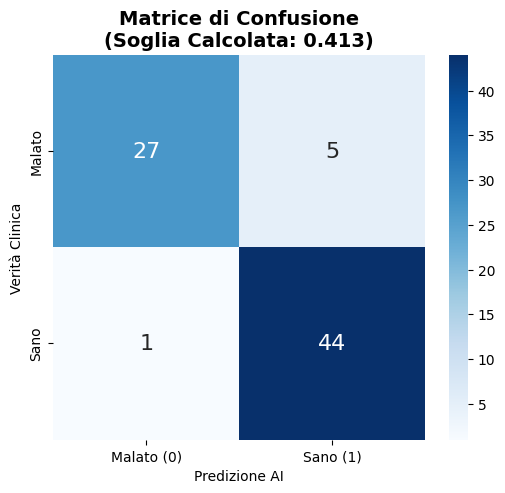


REPORT CLINICO CON SOGLIA OTTIMIZZATA:

              precision    recall  f1-score   support

      Malato       0.96      0.84      0.90        32
        Sano       0.90      0.98      0.94        45

    accuracy                           0.92        77
   macro avg       0.93      0.91      0.92        77
weighted avg       0.93      0.92      0.92        77



In [43]:
def trova_soglia_ottimale(modello, test_loader):
    """
    Esegue l'inferenza 1 sola volta (Zero OOM), calcola tutte le soglie possibili,
    trova la migliore usando l'Indice di Youden e plotta la Curva ROC.
    """
    modello.eval()
    all_y = []
    all_probs_malato = []
    
    print("Estrazione Probabilità in corso (1 solo passaggio per evitare OOM)...")
    with torch.no_grad():
        for img, etic in tqdm(test_loader, desc="Test Inferenza", colour='green'):
            img = img.to(device)
            out, _, _ = modello(img)
            
            probs = F.softmax(out, dim=1)
            prob_malato = probs[:, 0].cpu().numpy()
            
            all_probs_malato.extend(prob_malato)
            all_y.extend(etic.cpu().numpy())
            
    all_y = np.array(all_y)
    all_probs_malato = np.array(all_probs_malato)
    
   
    fpr, tpr, thresholds = roc_curve(all_y, all_probs_malato, pos_label=0)
    roc_auc = auc(fpr, tpr)
    
    youden_j = tpr - fpr
    
    best_idx = np.argmax(youden_j)
    soglia_migliore = thresholds[best_idx]
    
    print(f"La Soglia Ottimale calcolata con l'Indice di Youden è: {soglia_migliore:.4f}")
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classificatore Casuale')
    
    plt.scatter(fpr[best_idx], tpr[best_idx], marker='*', color='red', s=300, 
                label=f'Soglia Ottimale ({soglia_migliore:.2f})', zorder=5)
    
    plt.xlim([-0.02, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasso di Falsi Positivi (1 - Specificità)', fontsize=12)
    plt.ylabel('Tasso di Veri Positivi (Sensibilità/Recall)', fontsize=12)
    plt.title('Ottimizzazione della Soglia tramite Curva ROC', fontsize=15, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    
    all_pred = np.where(all_probs_malato >= soglia_migliore, 0, 1)
    cm = confusion_matrix(all_y, all_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Malato (0)', 'Sano (1)'], 
                yticklabels=['Malato', 'Sano'], annot_kws={"size": 16})
    plt.title(f'Matrice di Confusione\n(Soglia Calcolata: {soglia_migliore:.3f})', fontsize=14, fontweight='bold')
    plt.ylabel('Verità Clinica')
    plt.xlabel('Predizione AI')
    plt.show()
    
    print("\nREPORT CLINICO CON SOGLIA OTTIMIZZATA:\n")
    print(classification_report(all_y, all_pred, target_names=['Malato', 'Sano']))

    return soglia_migliore

soglia_ottimale = trova_soglia_ottimale(modello_aug, test_loader_aug)

Generazione CSV Errori con soglia a 0.4132...


Creazione CSV: 100%|██████████| 3/3 [01:10<00:00, 23.40s/it]


File CSV aggiornato e salvato: /home/andy/Documenti/Tesi-Magistrale/analisi_errori_ottimizzata.csv
--------------------------------------------------
NUOVO RIEPILOGO ERRORI:
Esito
Corretto                  71
FALSO NEGATIVO (Grave)     5
FALSO POSITIVO             1
Name: count, dtype: int64
--------------------------------------------------


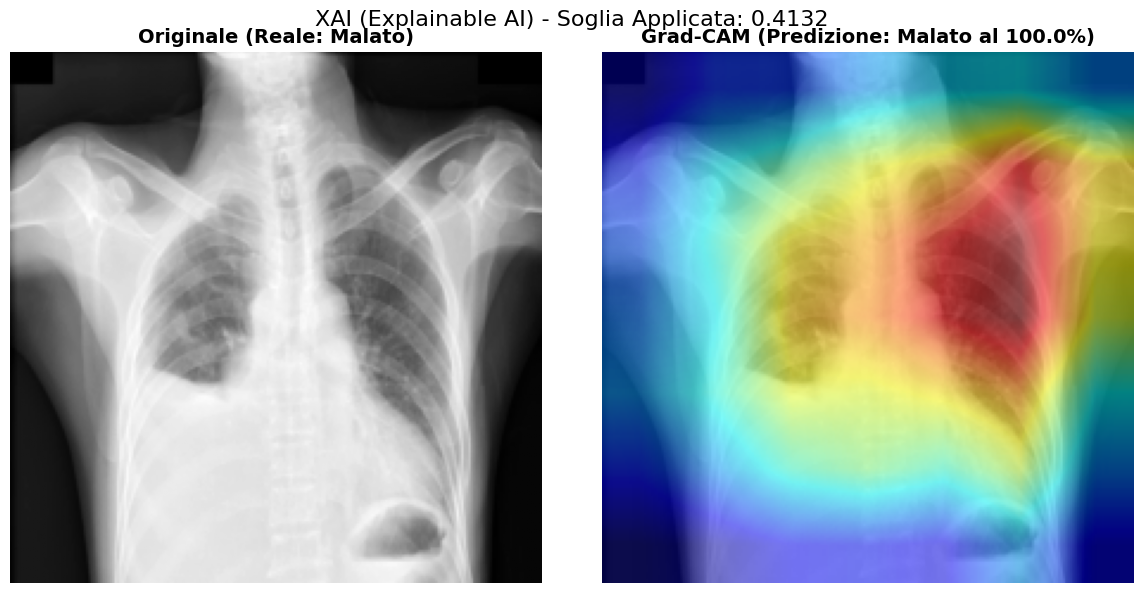

Grad-CAM Salvata: /home/andy/Documenti/Tesi-Magistrale/GradCAM_Tesi/Errore_Residuo_Ottimizzato.png


In [44]:
os.makedirs('/home/andy/Documenti/Tesi-Magistrale/GradCAM_Tesi', exist_ok=True)

def genera_gradcam_con_soglia(percorso_immagine, modello, transform_base, label_reale, nome_salvataggio, soglia):
    modello.eval() 
    target_layers = [modello.resnet.layer4[-1]]
    cam = GradCAM(model=modello, target_layers=target_layers)
    
    img_pil = Image.open(percorso_immagine).convert('L')
    img_tensor = transform_base(img_pil).unsqueeze(0).to(device)
    
    out, _, _ = modello(img_tensor)
    probs = F.softmax(out, dim=1)
    prob_malato = probs[0, 0].item()
    
    pred_idx = 0 if prob_malato >= soglia else 1
    
    classi = {0: 'Malato', 1: 'Sano'}
    predizione = classi[pred_idx]
    
    targets = [ClassifierOutputTarget(pred_idx)]
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]
    
    img_vis = img_tensor.cpu().squeeze().numpy()
    img_vis = (img_vis - img_vis.min()) / (img_vis.max() - img_vis.min())
    img_rgb = np.repeat(img_vis[:, :, np.newaxis], 3, axis=2)
    visualization = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_vis, cmap='gray')
    plt.title(f"Originale (Reale: {label_reale})", fontsize=14, fontweight='bold')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title(f"Grad-CAM (Predizione: {predizione} al {prob_malato*100:.1f}%)", fontsize=14, fontweight='bold')
    plt.axis('off')
    
    plt.suptitle(f"XAI (Explainable AI) - Soglia Applicata: {soglia:.4f}", fontsize=16, y=0.98)
    plt.tight_layout()
    
    percorso_out = f'/home/andy/Documenti/Tesi-Magistrale/GradCAM_Tesi/{nome_salvataggio}.png'
    plt.savefig(percorso_out, dpi=300, bbox_inches='tight') 
    plt.show()
    print(f"Grad-CAM Salvata: {percorso_out}")


with open('/home/andy/Documenti/Tesi-Magistrale/soglia_ottimale.json', 'w') as f:
    json.dump({"soglia_ottimale": soglia_ottimale}, f, indent=4)
        
    

percorso_nuovo_csv = '/home/andy/Documenti/Tesi-Magistrale/analisi_errori_ottimizzata.csv'
df_errori_nuovo = salva_analisi_errori_ottimizzata(modello_aug, test_loader_aug, soglia=soglia_ottimale, percorso_salvataggio_csv=percorso_nuovo_csv)

img_test = '/home/andy/Documenti/Tesi-Magistrale/data/RX_super/malati/34557d39d42d74a3355d509f340cfc8a.jp2' 
genera_gradcam_con_soglia(img_test, modello_aug, transform_base, label_reale="Malato", nome_salvataggio="Errore_Residuo_Ottimizzato", soglia=soglia_ottimale)